In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
from sklearn.datasets import load_iris

iris = load_iris()

# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Display first few rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [2]:
# No target column added → already suitable for clustering
X = df.copy()

print(X.shape)

(150, 4)


In [3]:
from sklearn.cluster import KMeans

# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

# Add cluster labels
df['KMeans_Cluster'] = kmeans_labels

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


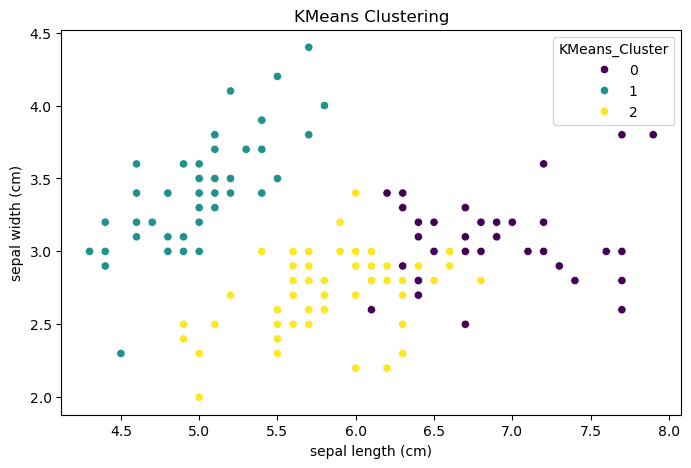

In [4]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df.iloc[:, 0],
    y=df.iloc[:, 1],
    hue=df['KMeans_Cluster'],
    palette='viridis'
)
plt.title("KMeans Clustering")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

In [5]:
from sklearn.cluster import AgglomerativeClustering

# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X)

# Add labels
df['HC_Cluster'] = hc_labels

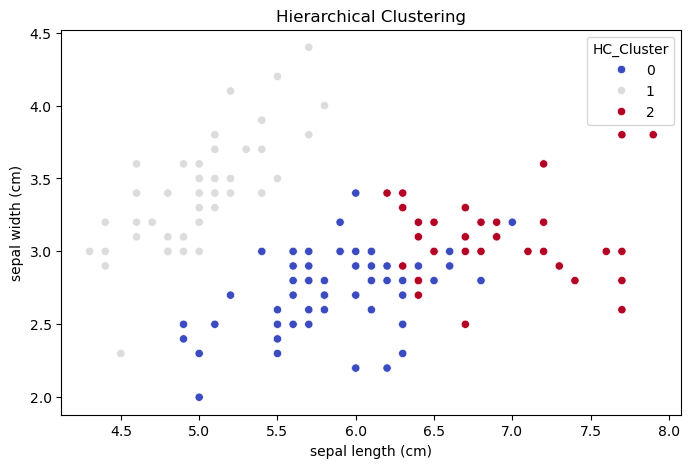

In [6]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x=df.iloc[:, 0],
    y=df.iloc[:, 1],
    hue=df['HC_Cluster'],
    palette='coolwarm'
)
plt.title("Hierarchical Clustering")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

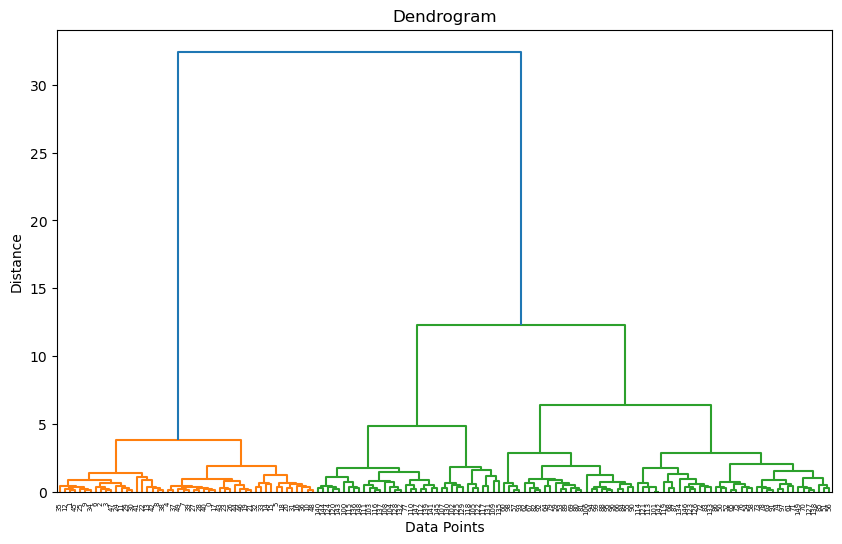

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()